In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,984 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123635 files and dire

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 파일 경로 설정
crime_file = '/content/crime_123.csv'
streetlamp_file = '/content/외국인비율 보정값.xlsx'

# 데이터 불러오기
crime_df = pd.read_csv(crime_file)  # CSV 파일 불러오기
streetlamp_df = pd.read_excel(streetlamp_file)  # 엑셀 파일 불러오기

# 데이터 확인
print(crime_df.head())
print(streetlamp_df.head())

        군구        중구      미추홀구       남동구       부평구        서구       계양구  \
0       살인  0.006962  0.017179  0.015435  0.002054  0.009002  0.010145   
1       강도  0.020886  0.026996  0.025083  0.028761  0.005401  0.023672   
2  강간.강제추행  0.772802  0.620913  0.329942  0.201329  0.428535  0.378767   
3       절도  6.084952  4.056800  1.724962  2.237219  2.337138  2.492424   
4       폭력  9.405916  5.639762  2.656906  2.652203  4.893946  4.372734   

        강화군       연수구  
0  0.028697  0.012832  
1  0.014348  0.012832  
2  0.258275  0.318239  
3  2.439269  3.169559  
4  4.835492  3.695681  
     군구  외국인비율
0   연수구  31.58
1   계양구  10.50
2    서구  20.34
3   부평구  28.31
4  미추홀구  22.30


In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

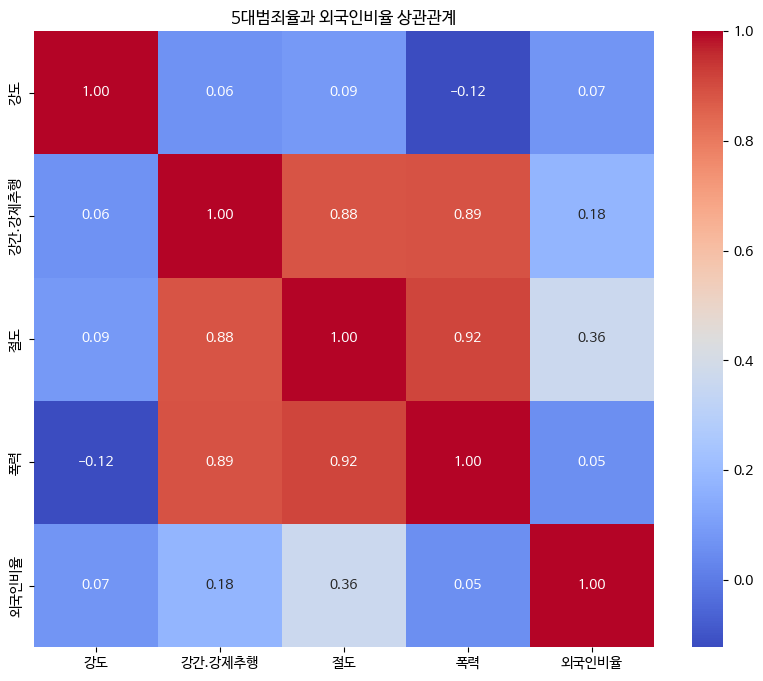

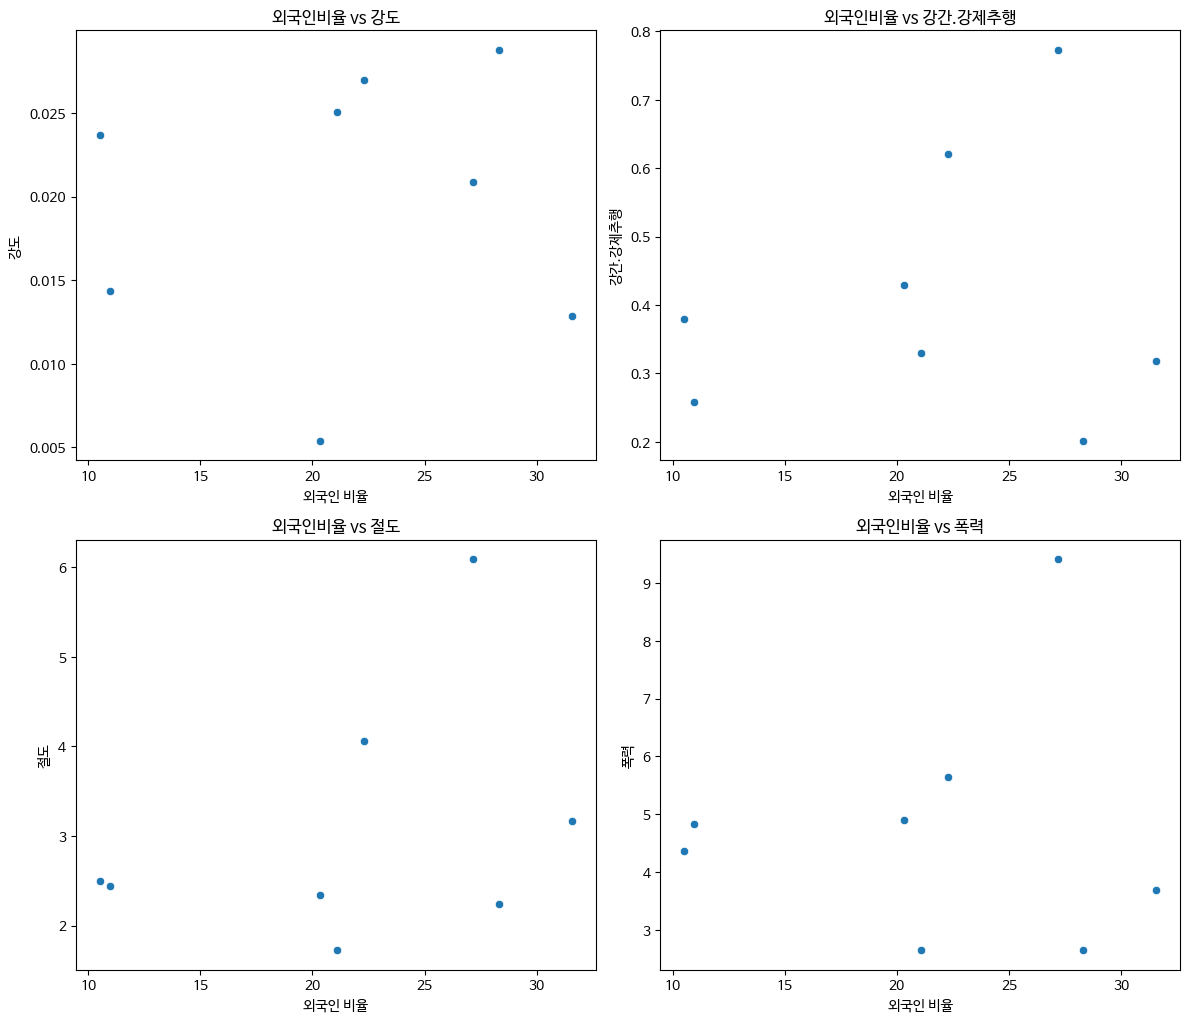

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 첫 번째 데이터: 군구별 외국인 비율
data_foreign_ratio = {
    '군구': ['연수구', '계양구', '서구', '부평구', '미추홀구', '남동구', '중구', '강화군'],
    '외국인비율': [31.58, 10.5, 20.34, 28.31, 22.3, 21.09, 27.17, 10.95]
}
df_foreign_ratio = pd.DataFrame(data_foreign_ratio)

# 두 번째 데이터: 군구별 범죄 발생 비율
data_crime_rate = {
    '군구': ['중구', '미추홀구', '남동구', '부평구', '서구', '계양구', '강화군', '연수구'],
    '살인': [0.006962, 0.017179, 0.015435, 0.002054, 0.009002, 0.010145, 0.028697, 0.012832],
    '강도': [0.020886, 0.026996, 0.025083, 0.028761, 0.005401, 0.023672, 0.014348, 0.012832],
    '강간.강제추행': [0.772802, 0.620913, 0.329942, 0.201329, 0.428535, 0.378767, 0.258275, 0.318239],
    '절도': [6.084952, 4.0568, 1.724962, 2.237219, 2.337138, 2.492424, 2.439269, 3.169559],
    '폭력': [9.405916, 5.639762, 2.656906, 2.652203, 4.893946, 4.372734, 4.835492, 3.695681]
}
df_crime_rate = pd.DataFrame(data_crime_rate)

# 데이터 합치기 (군구를 기준으로 병합)
merged_df = pd.merge(df_foreign_ratio, df_crime_rate, on='군구')

crime_columns = ['강도', '강간.강제추행', '절도', '폭력']
foreign_column = '외국인비율'

# 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(merged_df[crime_columns + [foreign_column]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("5대범죄율과 외국인비율 상관관계")
plt.show()

# 산점도 시각화
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15))
axes = axes.flatten()

for i, column in enumerate(crime_columns):
    sns.scatterplot(data=merged_df, x=foreign_column, y=column, ax=axes[i])
    axes[i].set_title(f"{foreign_column} vs {column}")
    axes[i].set_xlabel("외국인 비율")
    axes[i].set_ylabel(column)

for j in range(len(crime_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()